## Import Libraries

In [31]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


## Load Dataset

In [51]:
# Load your dataset
df = pd.read_excel("data/Online Retail.xlsx", engine="openpyxl")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## Data Cleaning

In [53]:
# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities (returns)
df = df[df['Quantity'] > 0]

# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create InvoiceMonth for grouping
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12


## Create Customer‑Month Aggregated Dataset

In [70]:
# Create customer-month aggregated dataset
monthly = (
    df.groupby(['CustomerID', 'InvoiceMonth'])
      .agg({
          'InvoiceNo': 'nunique',   # number of visits in that month
          'Quantity': 'sum',        # total items purchased
          'UnitPrice': 'mean'       # average price paid
      })
      .reset_index()
)

monthly.head()


,CustomerID,InvoiceMonth,InvoiceNo,Quantity,UnitPrice
0,12346,2011-01,1,74215,1.040000
1,12347,2010-12,1,319,2.890000
2,12347,2011-01,1,315,2.523103
3,12347,2011-04,1,483,2.595417
4,12347,2011-06,1,196,2.978889


## Creating the Target Variable (PurchasedNextMonth)

In [72]:
# Create target variable: did the customer purchase next month?
monthly['NextMonth'] = monthly.groupby('CustomerID')['InvoiceMonth'].shift(-1)

# Binary target: 1 = purchased next month, 0 = did not purchase
monthly['PurchasedNextMonth'] = (monthly['NextMonth'].notna()).astype(int)

monthly.head()


,CustomerID,InvoiceMonth,InvoiceNo,Quantity,UnitPrice,NextMonth,PurchasedNextMonth
0,12346,2011-01,1,74215,1.040000,NaT,0
1,12347,2010-12,1,319,2.890000,2011-01,1
2,12347,2011-01,1,315,2.523103,2011-04,1
3,12347,2011-04,1,483,2.595417,2011-06,1
4,12347,2011-06,1,196,2.978889,2011-08,1


## Selecting Features and Target

In [76]:
# 6. Selecting Features and Target
X = monthly[['InvoiceNo', 'Quantity', 'UnitPrice']]
y = monthly['PurchasedNextMonth']

## Train–Test Split

In [79]:
# 7. Train–Test Split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((10452, 3), (2613, 3))

## Feature Scaling (Standardization)

In [86]:
# 8. Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Training the First Model (Logistic Regression)

In [89]:
# 9. Training the First Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# Initialize the model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)


## Train Models : Logistic Regression, Random Forest

In [91]:
# 10. Model Evaluation (Accuracy, Precision, Recall, F1)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.6681974741676234
Precision: 0.668199233716475
Recall: 0.9994269340974212
F1 Score: 0.800918484500574

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.00      0.00       868
           1       0.67      1.00      0.80      1745

    accuracy                           0.67      2613
   macro avg       0.67      0.50      0.40      2613
weighted avg       0.67      0.67      0.54      2613



## Training a More Powerful Model (Random Forest)

In [94]:
# 11. Training a More Powerful Model (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions
rf_pred = rf.predict(X_test_scaled)


## Evaluating the Random Forest Model

In [97]:
# 12. Evaluating the Random Forest Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Print results
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1 Score:", rf_f1)

# Detailed classification report
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.6195943360122464
Random Forest Precision: 0.6856154226396441
Random Forest Recall: 0.7948424068767909
Random Forest F1 Score: 0.7361995753715499

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.27      0.32       868
           1       0.69      0.79      0.74      1745

    accuracy                           0.62      2613
   macro avg       0.54      0.53      0.53      2613
weighted avg       0.59      0.62      0.60      2613



## Code to Create RFM Features

In [104]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime if not already
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date (max date in dataset)
reference_date = df['InvoiceDate'].max()

# Group by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


## Create the Target Variable

In [113]:
# 1. Create a customer-month table
customer_month = df.groupby(['CustomerID', 'InvoiceMonth']).agg({
    'InvoiceNo': 'nunique'
}).reset_index()

# 2. Sort by CustomerID then month
customer_month = customer_month.sort_values(['CustomerID', 'InvoiceMonth'])

# 3. Create the target: did the customer return next month?
customer_month['ReturnedNextMonth'] = customer_month.groupby('CustomerID')['InvoiceMonth'].shift(-1).notnull().astype(int)

customer_month.head()



,CustomerID,InvoiceMonth,InvoiceNo,ReturnedNextMonth
0,12346,2011-01,1,0
1,12347,2010-12,1,1
2,12347,2011-01,1,1
3,12347,2011-04,1,1
4,12347,2011-06,1,1


## merge RFM with the target

In [117]:
model_df = rfm.merge(
    customer_month[['CustomerID', 'ReturnedNextMonth']],
    on='CustomerID',
    how='inner'
)

model_df.head()


,CustomerID,Recency,Frequency,Monetary,ReturnedNextMonth
0,12346,325,1,77183.6,0
1,12347,1,7,4310.0,1
2,12347,1,7,4310.0,1
3,12347,1,7,4310.0,1
4,12347,1,7,4310.0,1


# Train a New Model Using the Improved Features

In [129]:
# 15. Prepare features and target
#Prepare X and y
X = model_df[['Recency', 'Frequency', 'Monetary']]
y = model_df['ReturnedNextMonth']


In [131]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [133]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [135]:
# Train a Random Forest on the new features
from sklearn.ensemble import RandomForestClassifier

rf2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf2.fit(X_train_scaled, y_train)
rf2_pred = rf2.predict(X_test_scaled)


In [137]:
# Evaluate the new model
from sklearn.metrics import classification_report

print(classification_report(y_test, rf2_pred))


              precision    recall  f1-score   support

           0       0.47      0.41      0.44       868
           1       0.72      0.77      0.75      1745

    accuracy                           0.65      2613
   macro avg       0.60      0.59      0.59      2613
weighted avg       0.64      0.65      0.64      2613



# Add More Behavioral Features (Next Level Feature Engineering)

In [140]:
# Average basket size per customer
# Customers who buy more items per transaction behave differently
basket = df.groupby('CustomerID').agg({
    'Quantity': 'mean'
}).reset_index()

basket.columns = ['CustomerID', 'AvgBasketSize']


In [142]:
# Average unit price per customer
# Price‑sensitive customers behave differently from premium buyers.
avg_price = df.groupby('CustomerID').agg({
    'UnitPrice': 'mean'
}).reset_index()

avg_price.columns = ['CustomerID', 'AvgUnitPrice']


In [144]:
# Number of unique products
# Number of Unique Products Purchased
unique_products = df.groupby('CustomerID').agg({
    'StockCode': 'nunique'
}).reset_index()

unique_products.columns = ['CustomerID', 'UniqueProducts']


In [146]:
# Merge All New Features Into Your Model Dataset
model_df = model_df.merge(basket, on='CustomerID', how='left')
model_df = model_df.merge(avg_price, on='CustomerID', how='left')
model_df = model_df.merge(unique_products, on='CustomerID', how='left')

model_df.head()


,CustomerID,Recency,Frequency,Monetary,ReturnedNextMonth,AvgBasketSize,AvgUnitPrice,UniqueProducts
0,12346,325,1,77183.6,0,74215.000000,1.040000,1
1,12347,1,7,4310.0,1,13.505495,2.644011,103
2,12347,1,7,4310.0,1,13.505495,2.644011,103
3,12347,1,7,4310.0,1,13.505495,2.644011,103
4,12347,1,7,4310.0,1,13.505495,2.644011,103


# Train a Model With All Features (RFM + Behavioral Features)

In [149]:
# Define X and y
# Prepare full feature set
X = model_df[['Recency', 'Frequency', 'Monetary',
              'AvgBasketSize', 'AvgUnitPrice', 'UniqueProducts']]

y = model_df['ReturnedNextMonth']


In [151]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [153]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [155]:
# Train a Random Forest on the expanded features
from sklearn.ensemble import RandomForestClassifier

rf3 = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced'
)

rf3.fit(X_train_scaled, y_train)
rf3_pred = rf3.predict(X_test_scaled)


In [157]:
# Evaluate the improved model
from sklearn.metrics import classification_report

print(classification_report(y_test, rf3_pred))


              precision    recall  f1-score   support

           0       0.47      0.41      0.44       868
           1       0.72      0.77      0.74      1745

    accuracy                           0.65      2613
   macro avg       0.60      0.59      0.59      2613
weighted avg       0.64      0.65      0.64      2613



C:\Users\Mahsa\AppData\Local\Temp\ipykernel_18808\1773016230.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


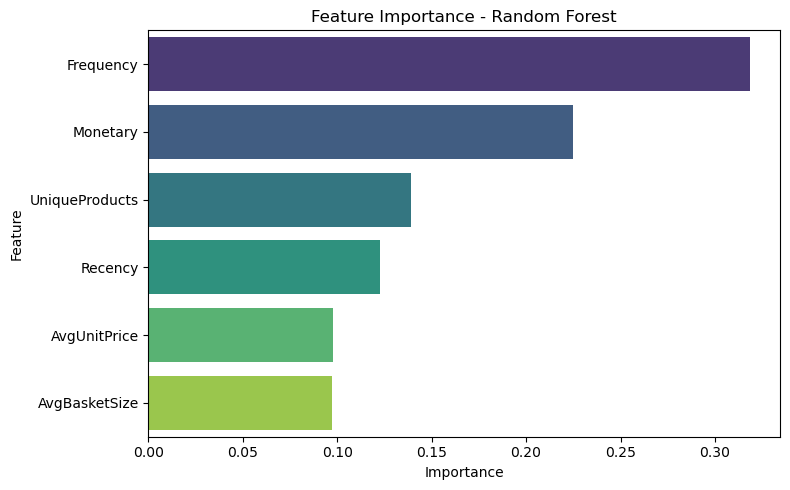

In [159]:
# Feature Importance Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = rf3.feature_importances_
feature_names = X.columns

# Create a DataFrame
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()
